Первым делом скачаем все необходимые зависимости

In [76]:
# !pip install stanza
# !pip install allennlp==2.10.1 allennlp-models==2.10.1
# !pip install torch
# !pip install pandas
# !pip install scikit-learn
# !pip install matplotlib seaborn

In [77]:
import torch
import random
import copy
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import numpy as np
import stanza

In [78]:
stanza.download('en')

nlp = stanza.Pipeline(
    'en',
    processors='tokenize,pos,lemma,depparse,constituency'
)

2026-04-20 20:49:29 INFO: Downloaded file to C:\Users\admin\stanza_resources\resources.json
2026-04-20 20:49:29 INFO: Downloading default packages for language: en (English) ...
2026-04-20 20:49:30 INFO: File exists: C:\Users\admin\stanza_resources\en\default.zip
2026-04-20 20:49:35 INFO: Finished downloading models and saved to C:\Users\admin\stanza_resources
2026-04-20 20:49:35 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-04-20 20:49:37 INFO: Downloaded file to C:\Users\admin\stanza_resources\resources.json
2026-04-20 20:49:37 WARNING: Language en package default expects mwt, which has been added
2026-04-20 20:49:38 INFO: Loading these models for language: en (English):
| Processor    | Package             |
--------------------------------------
| tokenize     | combined            |
| mwt          | combined            |
| pos    

In [79]:
def simple_srl_from_doc(doc):
    roles = []

    for sent in doc.sentences:
        for word in sent.words:
            if word.upos == "VERB":
                predicate = word.text
                args = {"V": predicate}

                for w in sent.words:
                    if w.head == word.id:
                        if w.deprel == "nsubj":
                            args["ARG0"] = w.text
                        elif w.deprel in ["obj", "dobj"]:
                            args["ARG1"] = w.text
                        elif w.deprel == "iobj":
                            args["ARG2"] = w.text

                roles.append(args)

    return roles

In [80]:
sentences = [
    "John gave Mary a book.",
    "Alice sent Bob an email.",
    "The teacher explained the lesson.",
    "Tom bought a car.",
    "Sarah wrote a letter.",
    "The company hired a manager.",
    "The chef cooked dinner.",
    "The dog chased the cat.",
    "Anna told a story.",
    "Mark built a house."
]

In [81]:
def corrupt_dependencies(doc, corruption_rate=0.3):
    corrupted_doc = copy.deepcopy(doc)

    for sent in corrupted_doc.sentences:
        words = sent.words
        for word in words:
            if random.random() < corruption_rate and word.head != 0:
                possible_heads = [w.id for w in words if w.id != word.id]
                word.head = random.choice(possible_heads)

    return corrupted_doc

In [82]:
def roles_to_set(role_list):
    """
    Преобразует [{'V': 'gave', 'ARG0': 'John', ...}]
    в множество троек (predicate, role, argument)
    """
    role_set = set()

    for frame in role_list:
        predicate = frame.get("V")
        for role, arg in frame.items():
            if role != "V":
                role_set.add((predicate, role, arg))

    return role_set


def compare_roles(gold_roles, pred_roles):
    gold_set = roles_to_set(gold_roles)
    pred_set = roles_to_set(pred_roles)

    true_pos = len(gold_set & pred_set)
    false_pos = len(pred_set - gold_set)
    false_neg = len(gold_set - pred_set)

    precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
    recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1

In [83]:
corruption_levels = [0.0, 0.1, 0.3, 0.5, 0.7]
runs = 10

means = []
stds = []

for level in corruption_levels:
    all_f1_scores = []

    for sentence in sentences:
        doc = nlp(sentence)
        baseline_roles = simple_srl_from_doc(doc)

        for i in range(runs):
            corrupted_doc = corrupt_dependencies(doc, corruption_rate=level)
            corrupted_roles = simple_srl_from_doc(corrupted_doc)

            _, _, f1 = compare_roles(baseline_roles, corrupted_roles)
            all_f1_scores.append(f1)

    avg_f1 = np.mean(all_f1_scores)
    std_f1 = np.std(all_f1_scores)

    means.append(avg_f1)
    stds.append(std_f1)

    print(f"Corruption {level}: Average F1 = {avg_f1}, Std = {std_f1}")

Corruption 0.0: Average F1 = 1.0, Std = 0.0
Corruption 0.1: Average F1 = 0.917, Std = 0.18405886739482744
Corruption 0.3: Average F1 = 0.7903333333333334, Std = 0.28171281673205983
Corruption 0.5: Average F1 = 0.7130000000000001, Std = 0.30473649819693954
Corruption 0.7: Average F1 = 0.5369999999999999, Std = 0.3583262014794155


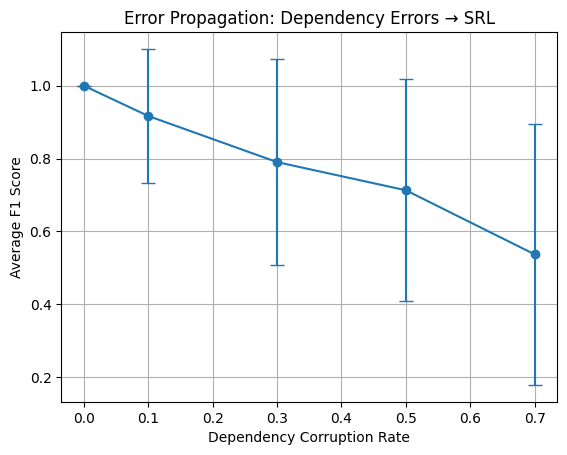

In [84]:
plt.errorbar(corruption_levels, means, yerr=stds, marker='o', capsize=5)
plt.xlabel("Dependency Corruption Rate")
plt.ylabel("Average F1 Score")
plt.title("Error Propagation: Dependency Errors → SRL")
plt.grid(True)
plt.show()

2 part. constituency

In [85]:
def get_first_label(node, label):
    if node.label == label:
        return node

    for child in node.children:
        result = get_first_label(child, label)
        if result:
            return result

    return None


def get_first_verb(node):
    if node.label.startswith("VB"):
        return node.leaf_labels()[0]

    for child in node.children:
        result = get_first_verb(child)
        if result:
            return result

    return None


def simple_srl_from_constituency(doc):
    roles = []

    for sent in doc.sentences:
        tree = sent.constituency

        # Спускаемся к S (если есть ROOT)
        if tree.label == "ROOT" and len(tree.children) > 0:
            tree = tree.children[0]

        args = {}

        # Найти NP и VP среди детей S
        subject_np = None
        vp = None

        for child in tree.children:
            if child.label == "NP" and subject_np is None:
                subject_np = child
            elif child.label == "VP" and vp is None:
                vp = child

        if subject_np:
            args["ARG0"] = " ".join(subject_np.leaf_labels())

        if vp:
            verb = get_first_verb(vp)
            if verb:
                args["V"] = verb

            obj_np = get_first_label(vp, "NP")
            if obj_np:
                args["ARG1"] = " ".join(obj_np.leaf_labels())

        if "V" in args:
            roles.append(args)

    return roles

Corrupt constituency

In [86]:
def corrupt_constituency(doc, corruption_rate=0.3):
    corrupted_doc = copy.deepcopy(doc)

    for sent in corrupted_doc.sentences:
        tree = sent.constituency

        # Спускаемся к S
        if tree.label == "ROOT" and len(tree.children) > 0:
            tree = tree.children[0]

        # Найти VP
        vp = None
        for child in tree.children:
            if child.label == "VP":
                vp = child
                break

        if vp:
            new_children = []
            for child in vp.children:
                # если это NP — можем удалить
                if child.label == "NP" and random.random() < corruption_rate:
                    continue
                new_children.append(child)

            vp.children = new_children

    return corrupted_doc

In [87]:
means_const = []
stds_const = []

for level in corruption_levels:
    all_f1_scores = []

    for sentence in sentences:
        doc = nlp(sentence)
        baseline_roles = simple_srl_from_constituency(doc)

        for i in range(runs):
            corrupted_doc = corrupt_constituency(doc, corruption_rate=level)
            corrupted_roles = simple_srl_from_constituency(corrupted_doc)

            _, _, f1 = compare_roles(baseline_roles, corrupted_roles)
            all_f1_scores.append(f1)

    avg_f1 = np.mean(all_f1_scores)
    std_f1 = np.std(all_f1_scores)

    means_const.append(avg_f1)
    stds_const.append(std_f1)

    print(f"[Constituency] Corruption {level}: Average F1 = {avg_f1}, Std = {std_f1}")

[Constituency] Corruption 0.0: Average F1 = 1.0, Std = 0.0
[Constituency] Corruption 0.1: Average F1 = 0.9533333333333333, Std = 0.12265579661982734
[Constituency] Corruption 0.3: Average F1 = 0.9350000000000002, Std = 0.14121496615680176
[Constituency] Corruption 0.5: Average F1 = 0.795, Std = 0.17928097128994666
[Constituency] Corruption 0.7: Average F1 = 0.7416666666666668, Std = 0.14790199457749043


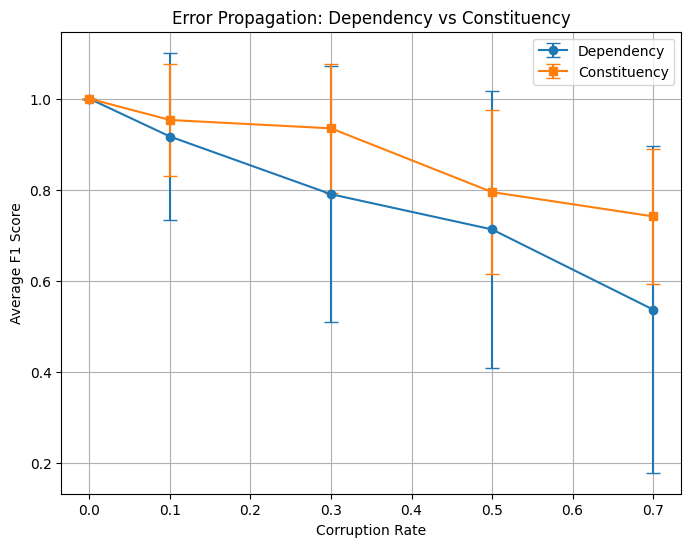

In [88]:
plt.figure(figsize=(8,6))

plt.errorbar(corruption_levels, means, yerr=stds, marker='o', capsize=5, label="Dependency")
plt.errorbar(corruption_levels, means_const, yerr=stds_const, marker='s', capsize=5, label="Constituency")

plt.xlabel("Corruption Rate")
plt.ylabel("Average F1 Score")
plt.title("Error Propagation: Dependency vs Constituency")
plt.legend()
plt.grid(True)
plt.show()

Hybrid part

In [89]:
def hybrid_srl(doc):
    dep_roles = simple_srl_from_doc(doc)
    const_roles = simple_srl_from_constituency(doc)

    # создаём словари по глаголу
    dep_dict = {frame["V"]: frame for frame in dep_roles if "V" in frame}
    const_dict = {frame["V"]: frame for frame in const_roles if "V" in frame}

    all_verbs = set(dep_dict.keys()) | set(const_dict.keys())

    hybrid_roles = []

    for verb in all_verbs:
        hybrid_frame = {"V": verb}

        dep_frame = dep_dict.get(verb, {})
        const_frame = const_dict.get(verb, {})

        # ARG0
        if "ARG0" in dep_frame:
            hybrid_frame["ARG0"] = dep_frame["ARG0"]
        elif "ARG0" in const_frame:
            hybrid_frame["ARG0"] = const_frame["ARG0"]

        # ARG1
        if "ARG1" in dep_frame:
            hybrid_frame["ARG1"] = dep_frame["ARG1"]
        elif "ARG1" in const_frame:
            hybrid_frame["ARG1"] = const_frame["ARG1"]

        # ARG2 (только dependency)
        if "ARG2" in dep_frame:
            hybrid_frame["ARG2"] = dep_frame["ARG2"]

        hybrid_roles.append(hybrid_frame)

    return hybrid_roles

In [90]:
means_hybrid = []
stds_hybrid = []

for level in corruption_levels:
    all_f1_scores = []

    for sentence in sentences:
        clean_doc = nlp(sentence)

        baseline_roles = hybrid_srl(clean_doc)

        for i in range(runs):
            corrupted_doc = corrupt_dependencies(clean_doc, corruption_rate=level)

            hybrid_roles_corrupted = hybrid_srl(corrupted_doc)

            _, _, f1 = compare_roles(baseline_roles, hybrid_roles_corrupted)
            all_f1_scores.append(f1)

    avg_f1 = np.mean(all_f1_scores)
    std_f1 = np.std(all_f1_scores)

    means_hybrid.append(avg_f1)
    stds_hybrid.append(std_f1)

    print(f"[Hybrid - Dep Noise] Corruption {level}: Average F1 = {avg_f1}, Std = {std_f1}")

[Hybrid - Dep Noise] Corruption 0.0: Average F1 = 1.0, Std = 0.0
[Hybrid - Dep Noise] Corruption 0.1: Average F1 = 0.9493333333333334, Std = 0.14302136592520404
[Hybrid - Dep Noise] Corruption 0.3: Average F1 = 0.8503333333333333, Std = 0.23732279939169582
[Hybrid - Dep Noise] Corruption 0.5: Average F1 = 0.7140000000000001, Std = 0.285780801781132
[Hybrid - Dep Noise] Corruption 0.7: Average F1 = 0.6873333333333334, Std = 0.31047562079994484


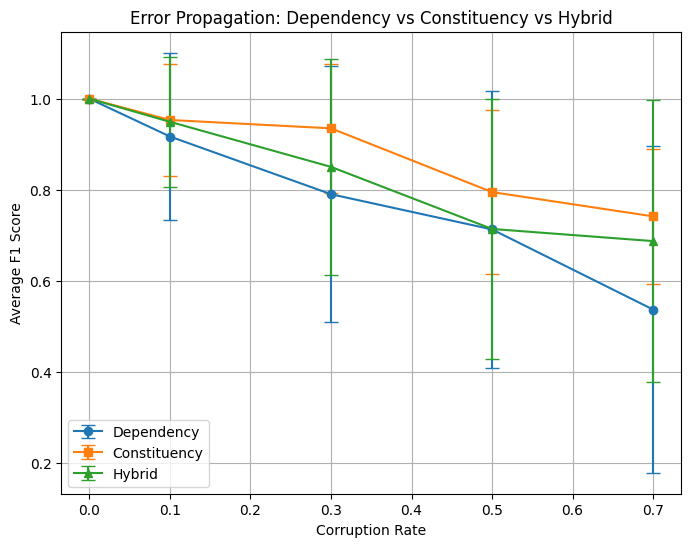

In [91]:
plt.figure(figsize=(8,6))

plt.errorbar(corruption_levels, means, yerr=stds,
             marker='o', capsize=5, label="Dependency")

plt.errorbar(corruption_levels, means_const, yerr=stds_const,
             marker='s', capsize=5, label="Constituency")

plt.errorbar(corruption_levels, means_hybrid, yerr=stds_hybrid,
             marker='^', capsize=5, label="Hybrid")

plt.xlabel("Corruption Rate")
plt.ylabel("Average F1 Score")
plt.title("Error Propagation: Dependency vs Constituency vs Hybrid")
plt.legend()
plt.grid(True)
plt.show()

In [94]:
results_table = pd.DataFrame({
    "Corruption": corruption_levels,
    "Dep Mean F1": means,
    "Dep Std": stds,
    "Const Mean F1": means_const,
    "Const Std": stds_const,
    "Hybrid Mean F1": means_hybrid,
    "Hybrid Std": stds_hybrid
})

print(results_table.round(3).to_string(index=False))

 Corruption  Dep Mean F1  Dep Std  Const Mean F1  Const Std  Hybrid Mean F1  Hybrid Std
        0.0        1.000    0.000          1.000      0.000           1.000       0.000
        0.1        0.917    0.184          0.953      0.123           0.949       0.143
        0.3        0.790    0.282          0.935      0.141           0.850       0.237
        0.5        0.713    0.305          0.795      0.179           0.714       0.286
        0.7        0.537    0.358          0.742      0.148           0.687       0.310
